In [176]:
## conda activate gpy_torch_env
import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate




## Forward Model

Solve spring problem
\begin{align}
        M x'' + C x' + K x = 0   
    \end{align}

where $M$ is a matrix with the mass values, $C$ is the matrix of dashpot coefficients, and $K$ is the matrix of stiffness parameters. Note that this problem is actually non-identifiable, as the problem can be written as
\begin{align}
        x'' + \tilde{C} x' + \tilde{K} x = 0   
    \end{align}
    where $\tilde{C} = M^{-1}C$ and $\tilde{K} = M^{-1}K$. Thus, we will assume that $M$ is known, but that $C$ and $K$ may be unknown (or convert the system to the second system).



We require the solution of the sensitivity system:
\begin{align}
    \frac{d\chi}{dt} &= \frac{\partial g}{\partial y} \frac{\partial y}{\partial \theta} + \frac{\partial g}{\partial \theta} \\
    &= \frac{\partial g}{\partial u} \chi + \frac{\partial g}{\partial \theta}
    \end{align}
where $\frac{\partial g}{\partial u}$ is the Jacobian of the system, $\bm{\chi}$ is the sensitivity of the states with respect to the parameters, and $\frac{\partial g}{\partial \bm{\theta}}$ are the derivatives with respect to the right hand side expressions. Again for numerical purposes we construct the relative variables for our system, i.e. scaled by the population $N$.

In [177]:
def coupled_sys(yall,t,params,m):
    # 8 states and 5x4=20 sensitivities
    (x1,x2,x3,x4,v1,v2,v3,v4,
     x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
     x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
     x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
     x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
     x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
     x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
     x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
     x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = yall
    sens = yall[8:]
    # Unpack parameters
    # k1,c1,k2,c2,k3,c3,k4,c4 = np.exp(params)
    k1,c1,k2,c2,k3,c3,k4,c4 = params
    m1,m2,m3,m4 = m
    # Jacobian of system
    dgdy = np.zeros((64,64))
    for i in range(8):
        ind = 8*i
        dgdy[ind,ind+4]     = 1.0
        dgdy[ind+1,ind+5]   = 1.0
        dgdy[ind+2,ind+6]   = 1.0
        dgdy[ind+3,ind+7]   = 1.0

        dgdy[ind+4,ind]   = -(k1+k2)/m1
        dgdy[ind+4,ind+1] = k2/m1
        dgdy[ind+4,ind+4] = -(c1+c2)/m1
        dgdy[ind+4,ind+5] = c2/m1
        
        dgdy[ind+5,ind]   = k2/m2
        dgdy[ind+5,ind+1] = -(k2+k3)/m2
        dgdy[ind+5,ind+2] = k3/m2
        dgdy[ind+5,ind+4] = c2/m2
        dgdy[ind+5,ind+5] = -(c2+c3)/m2
        dgdy[ind+5,ind+6] = c3/m2

        dgdy[ind+6,ind+1]   = k3/m3
        dgdy[ind+6,ind+2] = -(k3+k4)/m3
        dgdy[ind+6,ind+3] = k4/m3
        dgdy[ind+6,ind+5] = c3/m3
        dgdy[ind+6,ind+6] = -(c3+c4)/m3
        dgdy[ind+6,ind+7] = c4/m3

        dgdy[ind+7,ind+2] = k4/m4
        dgdy[ind+7,ind+3] = -k4/m4
        dgdy[ind+7,ind+6] = c4/m4
        dgdy[ind+7,ind+7] = -c4/m4 

        
    # Sensitivity vector should be column vector defined by dRhs1/dpar1, dRHS2/dpar1, dRHS3/dpar1, .... up to dRHS_N / dpar_N
    dgdpar = np.array([[0,0,0,0,-x1/m1,0,0,0,
                        0,0,0,0,-v1/m1,0,0,0,
                        0,0,0,0,(-x1+x2)/m1,(x1-x2)/m2,0,0,
                        0,0,0,0,(-v1+v2)/m1,(v1-v2)/m2,0,0,
                        0,0,0,0,0,(-x2+x3)/m2,(x2-x3)/m3,0,
                        0,0,0,0,0,(-v2+v3)/m2,(v2-v3)/m3,0,
                        0,0,0,0,0,0,(-x3+x4)/m3,(x3-x4)/m4,
                        0,0,0,0,0,0,(-v3+v4)/m3,(v3-v4)/m4]])

    # RHS equations
    F4 = 0.0
    # velocity derivatives (trivial)
    dx1 = v1
    dx2 = v2
    dx3 = v3
    dx4 = v4

    # acceleration equations (explicit scalar form)
    dv1 = ( - (c1 + c2)*v1 +   c2*v2  - (k1 + k2)*x1 +   k2*x2 ) / m1
    dv2 = (   c2*v1 - (c2 + c3)*v2 + c3*v3 + k2*x1 - (k2 + k3)*x2 + k3*x3) / m2
    dv3 = (   c3*v2 - (c3 + c4)*v3 + c4*v4  + k3*x2 - (k3 + k4)*x3 + k4*x4) / m3
    dv4 = (   c4*v3 - c4*v4 + k4*x3 - k4*x4 + F4 ) / m4

    ds = np.matmul(dgdy,sens) + dgdpar

    dYall = np.zeros(72)
    dYall[0:8] = [dx1,dx2,dx3,dx4,dv1,dv2,dv3,dv4]
    dYall[8:] = ds
    return dYall

def call_model(params,x):
    X0 = np.zeros(72)
    X0[3] = -5.0
    X0[7] = -2.0
    
    masses = [5.0,6.0,7.0,10.0]
    tspace = x
    # Solve the system
    solution = odeint(coupled_sys, X0, tspace, args=(params.detach().numpy(), masses))


    # Unpack solution and return model + sensitivities scaled by the total population
    (x1,x2,x3,x4,v1,v2,v3,v4,
     x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
     x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
     x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
     x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
     x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
     x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
     x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
     x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = solution.T
    

    return torch.stack([
            torch.tensor(x1), torch.tensor(x2), torch.tensor(x3), torch.tensor(x4),
            torch.tensor(v1), torch.tensor(v2), torch.tensor(v3), torch.tensor(v4),
            torch.tensor(x1k1), torch.tensor(x2k1), torch.tensor(x3k1), torch.tensor(x4k1),
            torch.tensor(v1k1), torch.tensor(v2k1), torch.tensor(v3k1), torch.tensor(v4k1),
            torch.tensor(x1c1), torch.tensor(x2c1), torch.tensor(x3c1), torch.tensor(x4c1),
            torch.tensor(v1c1), torch.tensor(v2c1), torch.tensor(v3c1), torch.tensor(v4c1),
            torch.tensor(x1k2), torch.tensor(x2k2), torch.tensor(x3k2), torch.tensor(x4k2),
            torch.tensor(v1k2), torch.tensor(v2k2), torch.tensor(v3k2), torch.tensor(v4k2),
            torch.tensor(x1c2), torch.tensor(x2c2), torch.tensor(x3c2), torch.tensor(x4c2),
            torch.tensor(v1c2), torch.tensor(v2c2), torch.tensor(v3c2), torch.tensor(v4c2),
            torch.tensor(x1k3), torch.tensor(x2k3), torch.tensor(x3k3), torch.tensor(x4k3),
            torch.tensor(v1k3), torch.tensor(v2k3), torch.tensor(v3k3), torch.tensor(v4k3),
            torch.tensor(x1c3), torch.tensor(x2c3), torch.tensor(x3c3), torch.tensor(x4c3),
            torch.tensor(v1c3), torch.tensor(v2c3), torch.tensor(v3c3), torch.tensor(v4c3),
            torch.tensor(x1k4), torch.tensor(x2k4), torch.tensor(x3k4), torch.tensor(x4k4),
            torch.tensor(v1k4), torch.tensor(v2k4), torch.tensor(v3k4), torch.tensor(v4k4),
            torch.tensor(x1c4), torch.tensor(x2c4), torch.tensor(x3c4), torch.tensor(x4c4),
            torch.tensor(v1c4), torch.tensor(v2c4), torch.tensor(v3c4), torch.tensor(v4c4) ])


In [178]:
N = 4
# torch.manual_seed(20)
## design variables 
n_grid = 200
t0, tf = 0.0, 30.0
dt = 0.01
x = torch.linspace(t0,tf,n_grid)
## true parameter 
# theta_true = torch.tensor(np.log([2.6,0.6,1.2,1.1,4.1,0.4,2.0,0.5]), requires_grad=False)
theta_true = torch.tensor([2.6,0.6,1.2,1.1,4.1,0.4,2.0,0.5], requires_grad=False)

true_sol = call_model(theta_true,x)# k_vals = 2.6 * np.ones(N)
# c_vals = 2.1 * np.ones(N)



In [179]:
print(np.shape(true_sol))

torch.Size([72, 200])


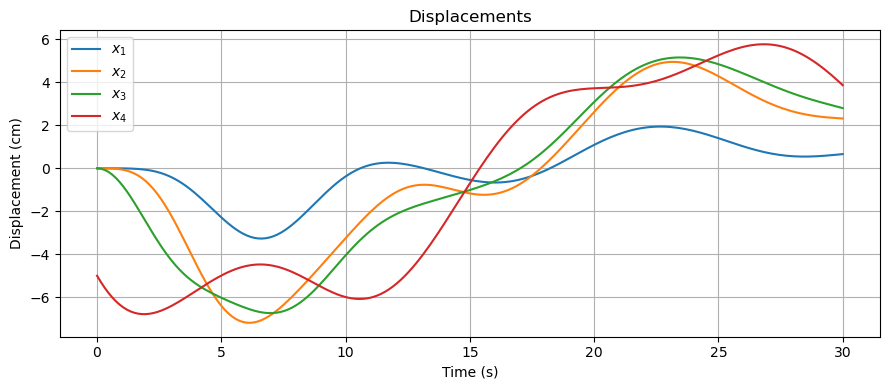

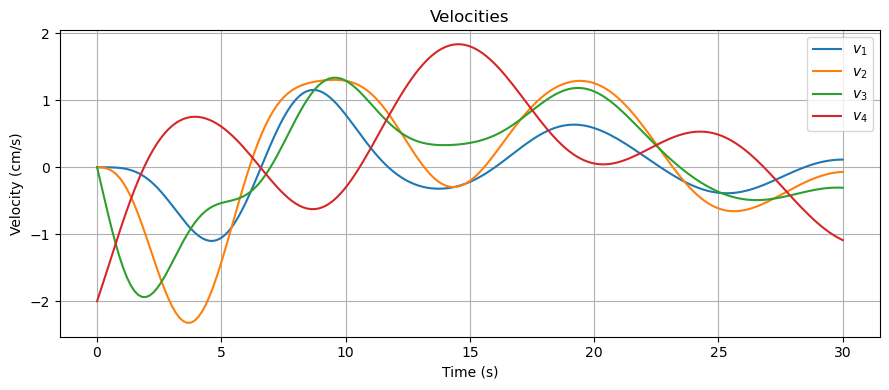

In [208]:
# Example: plot displacement of first 3 masses
plt.figure(figsize=(9,4))
for i in range(4):
    plt.plot(x, true_sol[i,:], label=f"$x_{i+1}$")
plt.xlabel("Time (s)"); plt.ylabel("Displacement (cm)"); plt.title("Displacements")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

# Example: plot velocity of first 3 masses
plt.figure(figsize=(9,4))
for i in range(4):
    plt.plot(x, true_sol[i+4,:], label=f"$v_{i+1}$")
plt.xlabel("Time (s)"); plt.ylabel("Velocity (cm/s)"); plt.title("Velocities")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

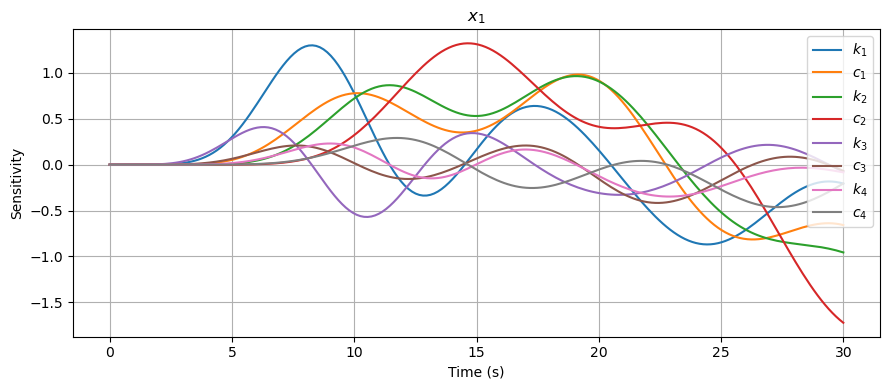

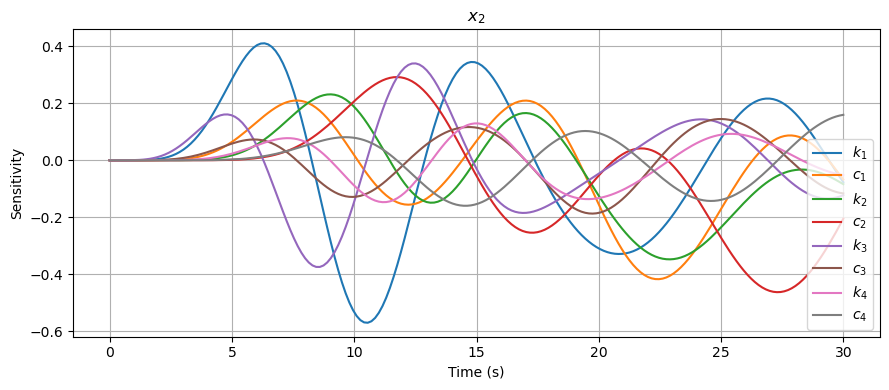

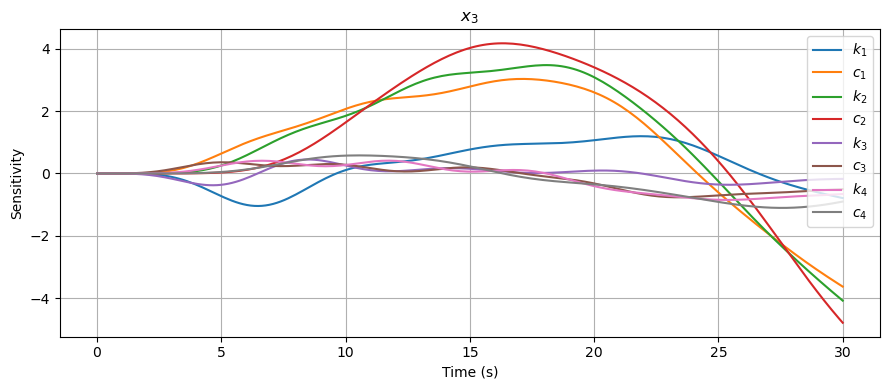

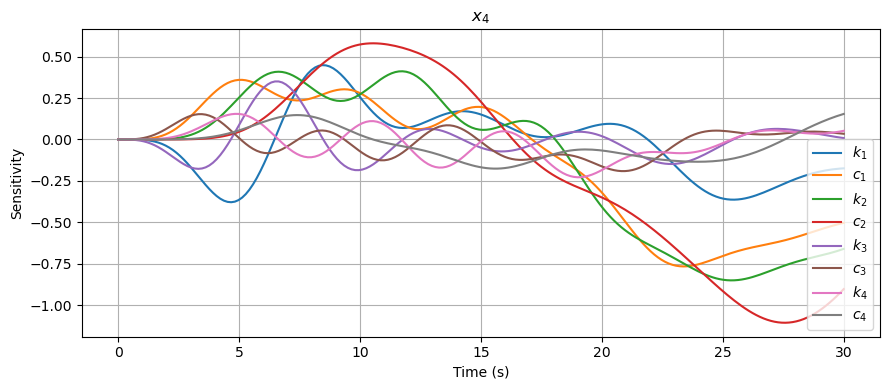

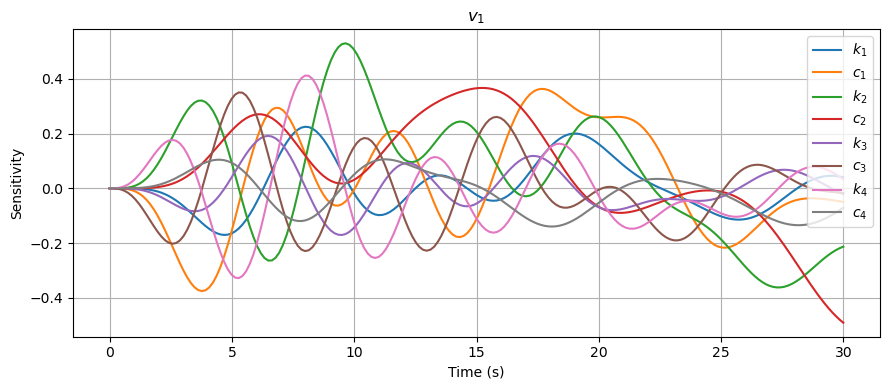

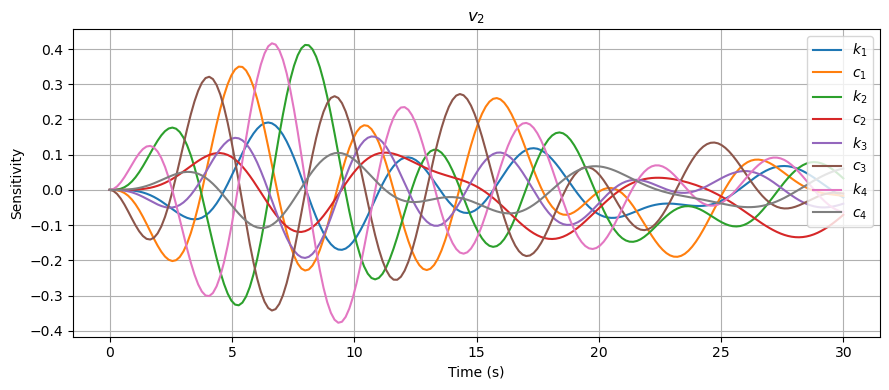

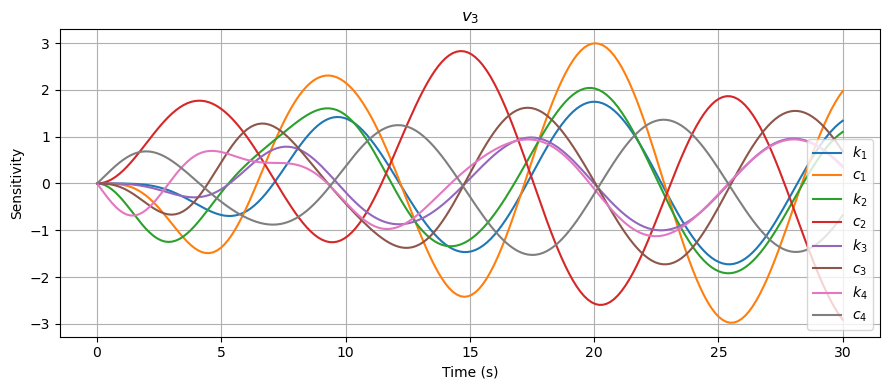

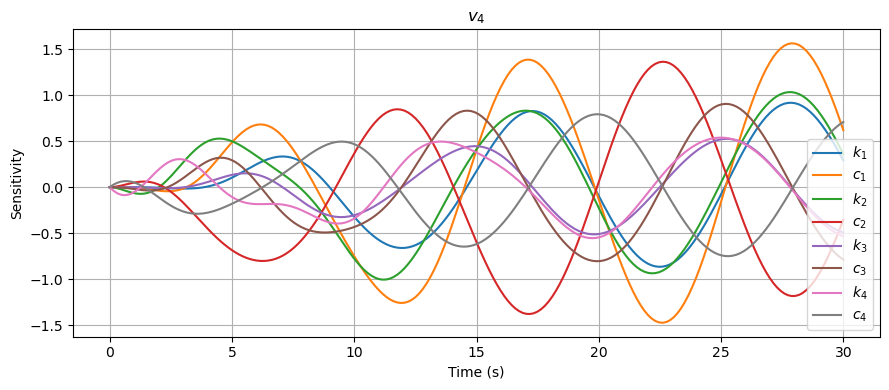

In [209]:
# Plot sensitivities
sens_names = ['$k_1$','$c_1$','$k_2$','$c_2$','$k_3$','$c_3$','$k_4$','$c_4$']
state_names = ['$x_1$','$x_2$','$x_3$','$x_4$','$v_1$','$v_2$','$v_3$','$v_4$']
for j in range(8):
    plt.figure(figsize=(9,4))
    for i in range(8):
        plt.plot(x, true_sol[8*(j+1)+i,:], label=sens_names[i])
        
    plt.xlabel("Time (s)"); plt.ylabel("Sensitivity"); plt.title(state_names[j])
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()


# Multivariate Orthogonal GP

In [181]:
def computeJitter(Cmat, target_min_eigval, min_jitter):
    eigvals = torch.linalg.eigvalsh(Cmat)
    lambda_min = eigvals.min()
    required_jitter = torch.clamp(target_min_eigval - lambda_min, min=min_jitter).item()
    return required_jitter  

def compute_jacobian(theta,x):
        # Break Jacobian into numerical solution of system 
        (x1,x2,x3,x4,v1,v2,v3,v4,
        x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
        x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
        x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
        x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
        x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
        x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
        x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
        x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = call_model(theta,x)
        # f1,f2,s11,s21,s12,s22 = solution.T
        # print(np.size(Smu,axis=0))
        jac = torch.empty(np.size(x1,axis=0),4,8)
        jac[:,0,0] = x1k1
        jac[:,0,1] = x1c1
        jac[:,0,2] = x1k2
        jac[:,0,3] = x1c2
        jac[:,0,4] = x1k3
        jac[:,0,5] = x1c3
        jac[:,0,6] = x1k4
        jac[:,0,7] = x1c4

        jac[:,1,0] = x2k1
        jac[:,1,1] = x2c1
        jac[:,1,2] = x2k2
        jac[:,1,3] = x2c2
        jac[:,1,4] = x2k3
        jac[:,1,5] = x2c3
        jac[:,1,6] = x2k4
        jac[:,1,7] = x2c4

        jac[:,2,0] = x3k1
        jac[:,2,1] = x3c1
        jac[:,2,2] = x3k2
        jac[:,2,3] = x3c2
        jac[:,2,4] = x3k3
        jac[:,2,5] = x3c3
        jac[:,2,6] = x3k4
        jac[:,2,7] = x3c4

        jac[:,3,0] = x4k1
        jac[:,3,1] = x4c1
        jac[:,3,2] = x4k2
        jac[:,3,3] = x4c2
        jac[:,3,4] = x4k3
        jac[:,3,5] = x4c3
        jac[:,3,6] = x4k4
        jac[:,3,7] = x4c4

        # jac[:,4,0] = v1k1
        # jac[:,4,1] = v1c1
        # jac[:,4,2] = v1k2
        # jac[:,4,3] = v1c2
        # jac[:,4,4] = v1k3
        # jac[:,4,5] = v1c3
        # jac[:,4,6] = v1k4
        # jac[:,4,7] = v1c4

        # jac[:,5,0] = v2k1
        # jac[:,5,1] = v2c1
        # jac[:,5,2] = v2k2
        # jac[:,5,3] = v2c2
        # jac[:,5,4] = v2k3
        # jac[:,5,5] = v2c3
        # jac[:,5,6] = v2k4
        # jac[:,5,7] = v2c4

        # jac[:,6,0] = v3k1
        # jac[:,6,1] = v3c1
        # jac[:,6,2] = v3k2
        # jac[:,6,3] = v3c2
        # jac[:,6,4] = v3k3
        # jac[:,6,5] = v3c3
        # jac[:,6,6] = v3k4
        # jac[:,6,7] = v3c4

        # jac[:,7,0] = v4k1
        # jac[:,7,1] = v4c1
        # jac[:,7,2] = v4k2
        # jac[:,7,3] = v4c2
        # jac[:,7,4] = v4k3
        # jac[:,7,5] = v4c3
        # jac[:,7,6] = v4k4
        # jac[:,7,7] = v4c4
        
        return jac    

class MultivariateOrthogonalKernel(torch.nn.Module):
    def __init__(self, C_func, call_model, gamma=1e-1, target_min_eigval=None, min_jitter=1e-10):
        super().__init__()
        self.J = C_func.num_tasks
        self.C_func = C_func
        # self.fmodel = fmodel
        self.fmodel = call_model
        self.gamma = gamma
        self.target_min_eigval = target_min_eigval
        self.min_jitter = min_jitter
    
    def forward(self, x, theta, xvol=None):
        n = len(x)
        if not xvol:
            xvol = 1./n
        C_x = self.gamma*self.C_func(x).evaluate().view(n, self.J, n, self.J).permute(0, 2, 1, 3) 
        
        J_theta_x = compute_jacobian(theta,x)#jacobian(lambda th: self.fmodel(x, th), theta) ## n x J x P
        h_theta_x_trans = xvol*torch.sum(torch.matmul(C_x, J_theta_x.unsqueeze(0)),dim=1)
        H_theta_inv = torch.linalg.inv(xvol*xvol*torch.sum(torch.matmul(J_theta_x.permute(0, 2, 1).unsqueeze(1), 
                                                   torch.matmul(C_x, J_theta_x.unsqueeze(0))),
                                        dim=(0, 1)))
        C_delta_x = C_x - torch.einsum("aip,pq,bjq->abij", h_theta_x_trans, H_theta_inv, h_theta_x_trans)
        C_delta_x_flat = C_delta_x.permute(0, 2, 1, 3).reshape(n * J, n * J)
        C_delta_x_flat = (C_delta_x_flat + C_delta_x_flat.T)/2.
        ##note, einsum implements
        #for i1 in range(n):
        #    for i2 in range(n):
        #        [i1, i2, ...] = h_theta_x_trans[i1,...] @ H_theta @ h_theta_x_trans[i2,...].T
        ## add jitter for numerical stabalization 
        if self.target_min_eigval:
            required_jitter = computeJitter(C_delta_x_flat, self.target_min_eigval, self.min_jitter)
            C_delta_x_flat = C_delta_x_flat + required_jitter * torch.eye(n*J)
        return C_delta_x_flat

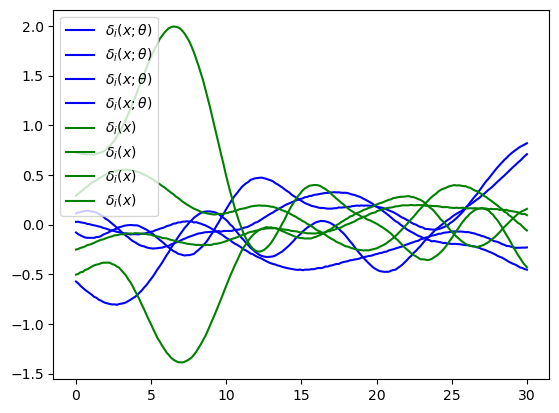

In [182]:
## define orthogonal discrepancy prior 
data_seed = 92
torch.manual_seed(data_seed)
J = 4
gamma_true = 0.2# was 0.01
bw_param_true = 3.2# Was 0.5
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.lengthscale = torch.tensor(bw_param_true)
marg_kernel.raw_lengthscale.requires_grad = False
## numerical stability 
target_min_eigval = 1e-6
min_jitter = 1e-10 

Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                    target_min_eigval=target_min_eigval, min_jitter=min_jitter)
C_delta_theta_true_xobs_flat = Cov_delta_theta(x, theta_true)

delta_ortho_theta_true_prior = MultivariateNormal(torch.zeros(n_grid * J), C_delta_theta_true_xobs_flat)

## add jitter for numerical stabality in unconstrained case
C_x_flat = gamma_true*Cov_unc(x).evaluate()
jitter = computeJitter(C_x_flat, target_min_eigval, min_jitter)
C_x_flat = C_x_flat + jitter*torch.eye(n_grid*J)
delta_unconstr_prior = MultivariateNormal(torch.zeros(n_grid * J), C_x_flat)

## compare to unrestricted prior  
delta_orth_sample = delta_ortho_theta_true_prior.rsample((1,)).view(1, len(x), J)
delta_uncon_sample =delta_unconstr_prior.rsample((1,)).view(1, len(x), J)

plt.figure()
for i in range(1):  
    plt.plot(x.numpy(), delta_orth_sample[i, :].detach().numpy(), 
                        label=r'$\delta_i(x; \theta)$' if i == 0 else "", c="b")
    plt.plot(x.numpy(), delta_uncon_sample[i, :].detach().numpy(), 
                            label=r'$\delta_i(x)$' if i == 0 else "", c="g")
plt.legend()


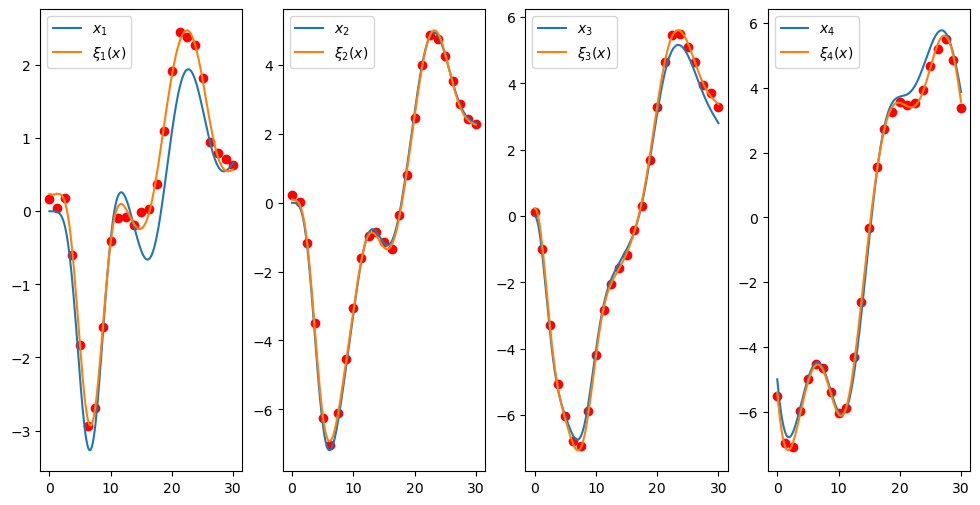

In [183]:
from scipy import interpolate

## sample true discrepancy
delta_disc_true = delta_ortho_theta_true_prior.rsample((1,)).view(n_grid, J)
## Defined the true phyiscal process 
(x1,x2,x3,x4,v1,v2,v3,v4,
        x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
        x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
        x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
        x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
        x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
        x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
        x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
        x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = call_model(theta_true,x)
f_true = torch.transpose(torch.reshape(torch.concat([x1,x2,x3,x4]),(4,len(x1))),0,1)
xi_true = torch.zeros((len(x1),J))

xi_true = f_true+delta_disc_true


## observation model 
n_obs = 25
x_obs = torch.linspace(0.0, x[-1], n_obs)

## local interpolation from discretized function repreresentation
xi_1_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,0].detach().numpy())
xi_2_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,1].detach().numpy())
xi_3_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,2].detach().numpy())
xi_4_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,3].detach().numpy())

xi_obs = torch.cat((torch.from_numpy(xi_1_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_2_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_3_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_4_interp(x_obs.detach().numpy())).float().view(-1,1)),
                    dim=-1)

## iid measurement error 
sigma_e = 0.1
y_obs = xi_obs + torch.normal(0, sigma_e, size=(n_obs,J))
## plot optimally calibrated model + true phyiscal process, 
fig, ax = plt.subplots(1,4,figsize=(12,6))

ax[0].plot(x.numpy(), f_true[:, 0].detach().numpy(), label=r'$x_1$')
ax[0].plot(x.numpy(), xi_true[:, 0].detach().numpy(), label=r'$\xi_1(x)$')
ax[0].scatter(x_obs.numpy(), y_obs[:, 0].detach().numpy(), c="r")

ax[1].plot(x.numpy(), f_true[:, 1].detach().numpy(), label=r'$x_2$')
ax[1].plot(x.numpy(), xi_true[:, 1].detach().numpy(), label=r'$\xi_2(x)$')
ax[1].scatter(x_obs.numpy(), y_obs[:, 1].detach().numpy(), c="r")

ax[2].plot(x.numpy(), f_true[:, 2].detach().numpy(), label=r'$x_3$')
ax[2].plot(x.numpy(), xi_true[:, 2].detach().numpy(), label=r'$\xi_3(x)$')
ax[2].scatter(x_obs.numpy(), y_obs[:, 2].detach().numpy(), c="r")

ax[3].plot(x.numpy(), f_true[:, 3].detach().numpy(), label=r'$x_4$')
ax[3].plot(x.numpy(), xi_true[:, 3].detach().numpy(), label=r'$\xi_4(x)$')
ax[3].scatter(x_obs.numpy(), y_obs[:, 3].detach().numpy(), c="r")


ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()


# Statistical Inference

In [184]:
# Try defining an update-able discrepancy
target_min_eigval = 1e-6
min_jitter = 1e-10 
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.initialize(lengthscale=torch.tensor(bw_param_true))
marg_kernel.raw_lengthscale.requires_grad = False   # freeze it if needed
GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(bw_param_true))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False
GP_Cov_MOP = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                target_min_eigval=target_min_eigval, min_jitter=min_jitter)
## inference

def potential_fn_MOP(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
   #  marg_kernel.lengthscale = torch.tensor(bw)
   #  Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
   #  Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_spring_model, gamma=gamma, 
   #                                                  target_min_eigval=target_min_eigval, min_jitter=min_jitter)
    GP_cov.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))
    GP_cov.gamma = gamma
    # Gaussian Process for discrepancy term
    C_delta_theta_true_xobs_flat = GP_cov(x_obs, theta)
    Cov = C_delta_theta_true_xobs_flat + (s2)*torch.eye(n_obs*J)
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    y_all = call_model(theta,x_obs)
    states = torch.transpose(torch.reshape(y_all[0:4,:],(4,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)

    ## posterior density (MJC: added try statement here because I kept getting non-SPD covariances)
    try:
       post_density = dist.MultivariateNormal(f_x_flat, Cov)
       PD_value = post_density.log_prob(y_obs.view(n_obs*J)) # EQ 17 IN OUR METHODS
       SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    except:
       PD_value = torch.tensor(-torch.inf)
       SS = torch.inf
    return PD_value, SS



GPtheta = torch.tensor([0.1,1])
potential_fn_MOP(theta_true,GPtheta,GP_Cov_MOP,sigma_e**2)



def potential_fn_IND(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))
    # GP_cov.gamma = gamma
    # Gaussian Process for discrepancy term
    Cov = gamma*GP_cov(x_obs).evaluate() + (s2)*torch.eye(n_obs*J)
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    y_all = call_model(theta,x_obs)
    states = torch.transpose(torch.reshape(y_all[0:4,:],(4,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)
    # print(f_x_flat)
    ## posterior density 
    post_density = dist.MultivariateNormal(f_x_flat, Cov)
    SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    return post_density.log_prob(y_obs.view(n_obs*J)), SS
    
GPtheta = torch.tensor([0.1,1])
print(potential_fn_IND(theta_true,GPtheta,GP_Cov_unc,sigma_e**2))

(tensor(-3.7182, grad_fn=<SubBackward0>), tensor(10.0206, dtype=torch.float64))


In [185]:
def adaptive_metropolis(post_func, data, theta0, s20, k0, M, covar, UB, LB, GP_cov):
    # Note: I removed the prior from this because we have uniform priors on theta and fixed discrepancy
    n_par = len(theta0)
    chain = torch.zeros((n_par, M))
    lik_chain = torch.zeros(M,1)
    s2chain = torch.zeros(M,1)
    n_y = len(data)
    print(n_y)

    if covar is None or len(covar) == 0:
        covar = torch.eye(n_par) * 0.1 * torch.abs(theta0)
    
    def lik_func(theta,thetaGP,s2):
        return post_func(theta,thetaGP,GP_cov,s2)
    
    chain[:, 0] = theta0
    thetamodel = theta0[:n_par-2]
    thetaGP    = np.exp(theta0[n_par-2:])
    lik_old, ss_old = lik_func(thetamodel,thetaGP,s20)
    sig_s = ss_old / (n_y - n_par)  # Estimate of error variance
    R = torch.linalg.cholesky(covar)
    print(thetamodel,thetaGP,ss_old,sig_s)


    # Error variance hyperparameters
    n_s = 0.01  # For inverse gamma
    aval = 0.5 * (n_s + n_y)  # This is constant
    bval = 0.5 * (n_s * sig_s + ss_old)
    s2chain[0] = invgamma.rvs(aval, scale=bval)
    # print(s2chain[0])
    # Initialize covariance estimates
    Vk = covar
    theta_bar = theta0
    Ip = torch.eye(n_par) * 1e-12  # Small jitter on diagonal for stability
    sp_cov = (2.38 ** 2) / n_par

    num_acc = 0
    prob_acc = np.log(uniform.rvs(size=M))
    for i in range(1, M):
        # given discrepancy value previously, compute log-likelihood with covariance given by
        # the MOP approach
        theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)

        if torch.sum(theta_star>UB).detach()>0 or torch.sum(theta_star<LB).detach()>0:
            lik_star = torch.inf
            acc_prob = -torch.inf
            ss_star = torch.inf
        else:
            thetamodel = theta_star[0:n_par-2]
            thetaGP    = np.exp(theta_star[n_par-2:])
            lik_old, ss_old   = lik_func(chain[0:n_par-2,i-1],np.exp(chain[n_par-2:,i-1]),s2chain[i-1])
            lik_star, ss_star = lik_func(thetamodel,thetaGP,s2chain[i-1])
            # if torch.abs(lik_star)>1e10:
                # acc_prob = 0.0
            # else:
            acc_prob = (lik_star) - (lik_old)
              # Recompute for the same s2 value
        
        
        if acc_prob > prob_acc[i]:
            ss_old = ss_star
            chain[:, i] = theta_star
            lik_old = lik_star
            num_acc += 1
        else:
            chain[:, i] = chain[:, i - 1]
            
        lik_chain[i]=lik_old

        # Gibbs step on hyperparameter
        bval = 0.5 * (n_s * sig_s + ss_old)
        s2chain[i] = np.minimum(invgamma.rvs(aval, scale=bval),1e4)
        # print(acc_prob,prob_acc[i],s2chain[i])

        if i % 1000 == 0:
            print('Percent done:',i/M*100)
            print('Acceptance rate:')
            print((num_acc / i) * 100)
            print(lik_star,lik_old,acc_prob)
        # Update covariance and mean parameter
        theta_bar_old = theta_bar
        theta_bar = (i / (i + 1)) * theta_bar_old + chain[:, i] / (i + 1)
        Vk = ((i - 1) * Vk / i + (sp_cov / i) * (i * torch.outer(theta_bar_old, theta_bar_old) -
             (i + 1) * torch.outer(theta_bar, theta_bar) + torch.outer(chain[:, i], chain[:, i]) + Ip))
        
        if i % k0 == 0:  # Update covariance in sampling
            Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)
            R = torch.linalg.cholesky(Vk)
            # print(Vk)

    print('Acceptance rate:')
    print((num_acc / M) * 100)
    # print(Vk)

    return chain, lik_chain, s2chain

In [186]:
bw_param_true

3.2

In [187]:
print(LB<theta_all_true)
print(UB>theta_all_true)
print(theta_all_true)

tensor([True, True, True, True, True, True, True, True, True, True])
tensor([True, True, True, True, True, True, True, True, True, True])
tensor([ 2.6000,  0.6000,  1.2000,  1.1000,  4.1000,  0.4000,  2.0000,  0.5000,
        -1.6094,  1.1632], dtype=torch.float64)


In [188]:
# LB = -5*torch.ones(len(theta_true))
# UB = 3*torch.ones(len(theta_true))
# UB = torch.cat((UB, torch.tensor([np.log(0.1), np.log(2)])))
# LB = torch.cat((LB, torch.tensor([np.log(0.0001), np.log(0.1)])))

LB = 0.1*torch.ones(len(theta_true))
UB = 10*torch.ones(len(theta_true))
UB = torch.cat((UB, torch.tensor([np.log(0.5), np.log(5)])))
LB = torch.cat((LB, torch.tensor([np.log(0.0001), np.log(0.1)])))
theta_all_true = torch.cat((theta_true,torch.tensor([np.log(gamma_true),np.log(bw_param_true)])))


k0 = 1000 # make this less than M to actually make this the AM; otherwise its MH
M = 10000
covar = torch.eye(len(theta_all_true)) * 0.0001 * torch.abs(theta_all_true)



In [189]:

chain_IND, lik_chain_IND, s2_IND = adaptive_metropolis(post_func=potential_fn_IND, data=y_obs.view(n_obs*J), theta0=theta_all_true, s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB, GP_cov=GP_Cov_unc)
chain_MOP, lik_chain_MOP, s2_MOP = adaptive_metropolis(post_func=potential_fn_MOP, data=y_obs.view(n_obs*J), theta0=theta_all_true, s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB, GP_cov=GP_Cov_MOP)

100
tensor([2.6000, 0.6000, 1.2000, 1.1000, 4.1000, 0.4000, 2.0000, 0.5000],
       dtype=torch.float64) tensor([0.2000, 3.2000], dtype=torch.float64) tensor(10.0207, dtype=torch.float64) tensor(0.1113, dtype=torch.float64)


C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\2399148317.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta0[n_par-2:])
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\2399148317.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\2399148317.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta_star[n_par-2:])
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\2399148317.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lik_old, ss_old   = 

Percent done: 10.0
Acceptance rate:
76.0
tensor(-32.1453, grad_fn=<SubBackward0>) tensor(-32.1453, grad_fn=<SubBackward0>) tensor(-0.0450, grad_fn=<SubBackward0>)


C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\2399148317.py:87: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)


Percent done: 20.0
Acceptance rate:
55.800000000000004
inf tensor(-49.9263, grad_fn=<SubBackward0>) -inf
Percent done: 30.0
Acceptance rate:
43.766666666666666
tensor(-35.9062, grad_fn=<SubBackward0>) tensor(-32.6767, grad_fn=<SubBackward0>) tensor(-3.2295, grad_fn=<SubBackward0>)
Percent done: 40.0
Acceptance rate:
36.725
tensor(-37.0331, grad_fn=<SubBackward0>) tensor(-26.2426, grad_fn=<SubBackward0>) tensor(-10.7905, grad_fn=<SubBackward0>)
Percent done: 50.0
Acceptance rate:
31.419999999999998
tensor(-28.6407, grad_fn=<SubBackward0>) tensor(-19.7794, grad_fn=<SubBackward0>) tensor(-8.8614, grad_fn=<SubBackward0>)
Percent done: 60.0
Acceptance rate:
27.416666666666668
tensor(-21.1486, grad_fn=<SubBackward0>) tensor(-20.0333, grad_fn=<SubBackward0>) tensor(-1.1153, grad_fn=<SubBackward0>)
Percent done: 70.0
Acceptance rate:
24.585714285714285
tensor(-36.0671, grad_fn=<SubBackward0>) tensor(-18.8984, grad_fn=<SubBackward0>) tensor(-17.1687, grad_fn=<SubBackward0>)
Percent done: 80.0
A

1.2162887


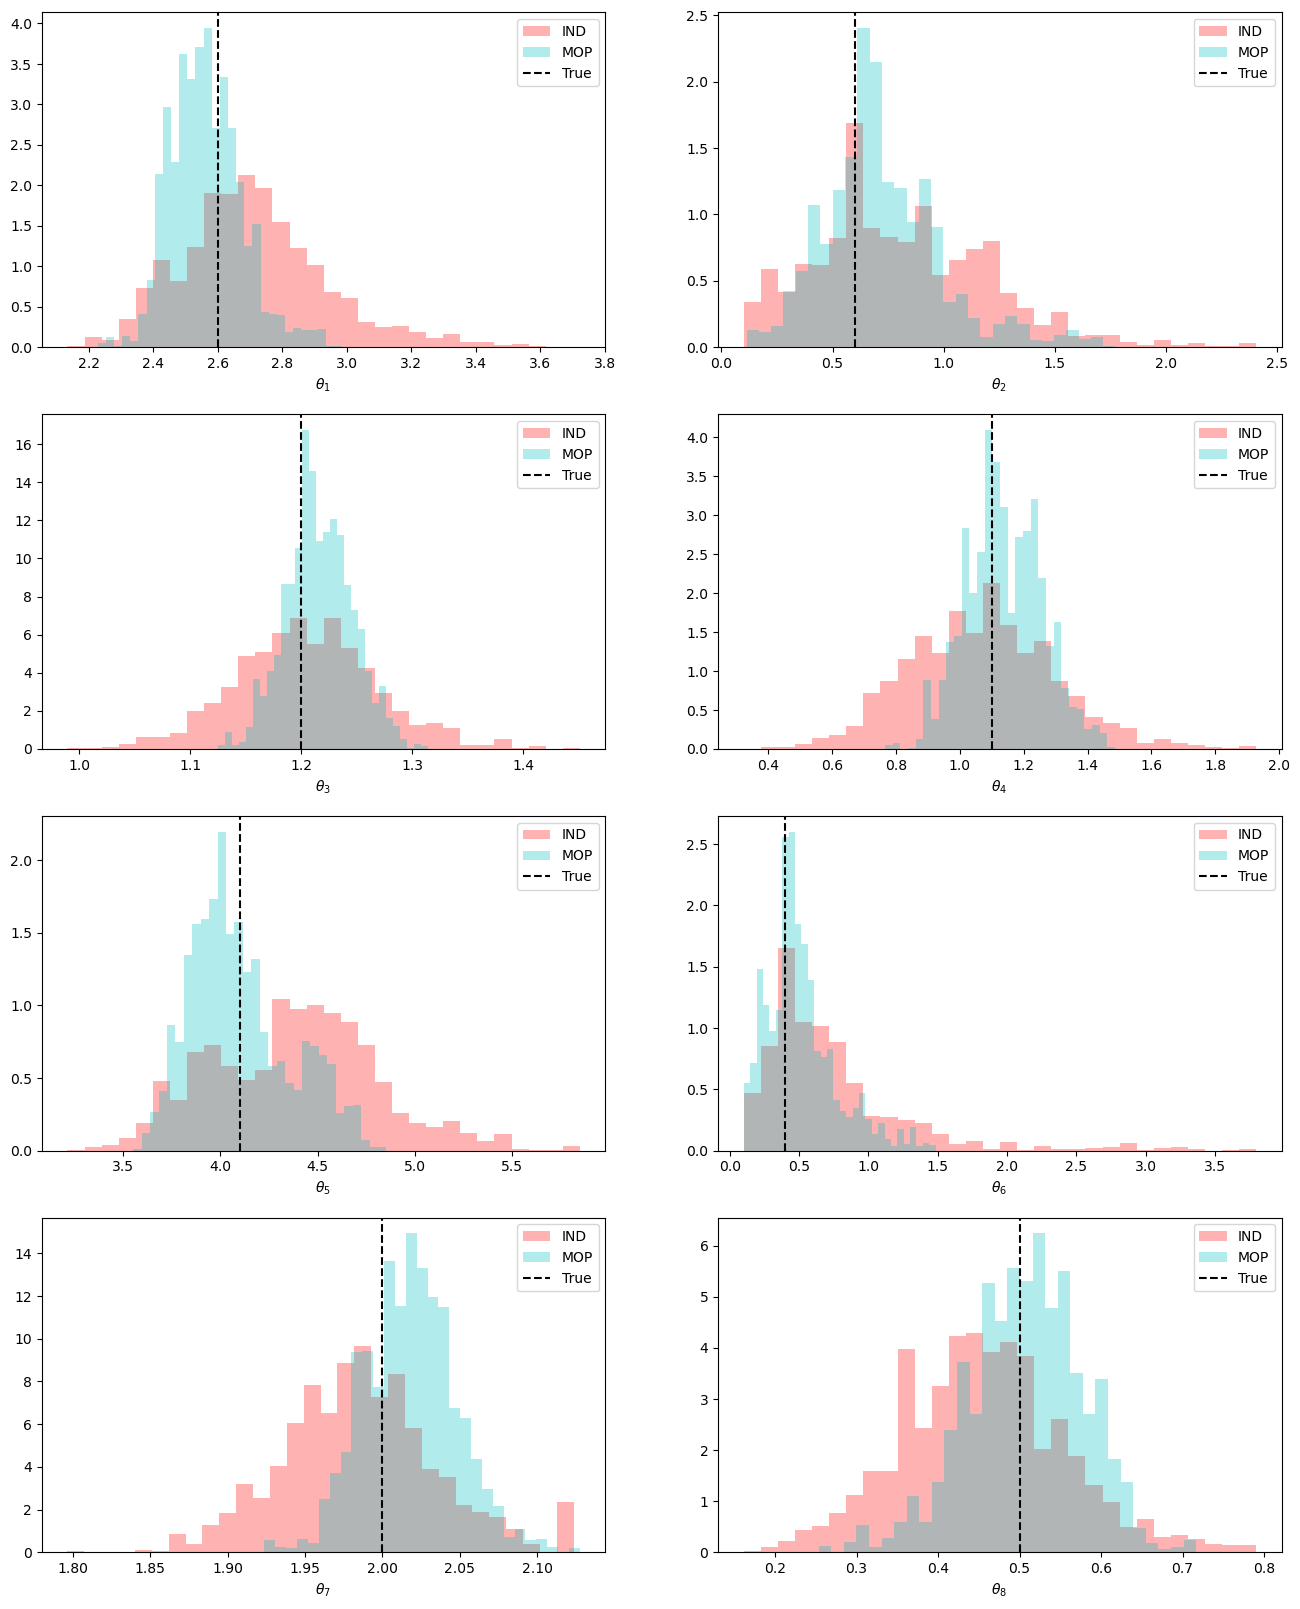

In [190]:
# Analyze the results
print(np.mean(chain_MOP[2,:].detach().numpy()))
# Plot the results
plt.figure(figsize=(16, 20))
plt.subplot(4, 2, 1)
plt.hist(chain_IND[0,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[0,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[0].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.legend()
plt.xlabel(r'$\theta_1$ ')

plt.subplot(4, 2, 2)
plt.hist(chain_IND[1,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[1,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[1].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_2$ ')
plt.legend()

plt.subplot(4, 2, 3)
plt.hist(chain_IND[2,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[2,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[2].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_3$ ')
plt.legend()

plt.subplot(4, 2, 4)
plt.hist(chain_IND[3,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[3,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[3].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_4$ ')
plt.legend()

plt.subplot(4, 2, 5)
plt.hist(chain_IND[4,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[4,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[4].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_5$ ')
plt.legend()

plt.subplot(4, 2, 6)
plt.hist(chain_IND[5,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[5,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[5].detach(), color='k', linestyle='--', label='True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_6$ ')
plt.legend()

plt.subplot(4, 2, 7)
plt.hist(chain_IND[6,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[6,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[6].detach(), color='k', linestyle='--', label=f'True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_7$ ')
plt.legend()

plt.subplot(4, 2, 8)
plt.hist(chain_IND[7,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='IND')
plt.hist(chain_MOP[7,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='MOP')
plt.axvline(theta_true[7].detach(), color='k', linestyle='--', label=f'True')
# plt.xlim(param_ranges[:,0])
plt.xlabel(r'$\theta_8$ ')
plt.legend()


torch.Size([10, 500])


In [215]:
## posterior inference on the discrepancy term (on the grid, need to update to off grid )
theta_samp_IND = chain_IND[:,M-5000:M:10]
theta_samp_MOP = chain_MOP[:,M-5000:M:10]
s2_samp_IND    = s2_IND[M-5000:M:10]
s2_samp_MOP    = s2_MOP[M-5000:M:10]

num_samp = len(theta_samp_IND[0,:])

f_IND = np.zeros((num_samp,4,n_grid))
f_MOP = np.zeros((num_samp,4,n_grid))

disc_IND = np.zeros((num_samp,n_grid,4))
disc_MOP = np.zeros((num_samp,n_grid,4))

# Try defining an update-able discrepancy
target_min_eigval = 1e-6
min_jitter = 1e-10 
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.initialize(lengthscale=torch.tensor(bw_param_true))
marg_kernel.raw_lengthscale.requires_grad = False   # freeze it if needed
GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(bw_param_true))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False
GP_Cov_MOP = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                target_min_eigval=target_min_eigval, min_jitter=min_jitter)
## inference

for i in range(num_samp):
    param_IND = theta_samp_IND[0:8,i]
    param_MOP = theta_samp_MOP[0:8,i]
    
    (x1,x2,x3,x4,v1,v2,v3,v4,
     x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
     x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
     x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
     x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
     x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
     x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
     x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
     x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = call_model(param_IND,x)
    f_IND[i,:,:] = x1,x2,x3,x4

    (x1,x2,x3,x4,v1,v2,v3,v4,
     x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
     x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
     x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
     x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
     x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
     x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
     x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
     x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) =  call_model(param_MOP,x)
    f_MOP[i,:,:] = x1,x2,x3,x4

    g_IND,bw_IND = np.exp(theta_samp_IND[8:,i])
    g_MOP,bw_MOP = np.exp(theta_samp_MOP[8:,i])

    # IND
    GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw_IND]))
    C_x_IND = g_IND*GP_Cov_unc(x).evaluate() #+ s2_samp_IND[i]*torch.eye(n_grid*J)
    jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
    C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
    IND_GP =  MultivariateNormal(torch.zeros(n_grid * J), C_x_IND)
    disc_IND[i,:,:] = IND_GP.rsample((1,)).view(n_grid, J).detach()
    # MOP
    GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw_MOP]))
    GP_Cov_MOP.gamma = g_MOP
    C_delta_theta_true_xobs_flat = GP_Cov_MOP(x, param_MOP) #+ (s2_samp_MOP[i])*torch.eye(n_grid*J)
    MOP_GP = MultivariateNormal(torch.zeros(n_grid * J), C_delta_theta_true_xobs_flat)
    disc_MOP[i,:,:] = MOP_GP.rsample((1,)).view(n_grid, J).detach()





C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\1199247704.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  g_IND,bw_IND = np.exp(theta_samp_IND[8:,i])
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\1199247704.py:55: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  g_MOP,bw_MOP = np.exp(theta_samp_MOP[8:,i])
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\1199247704.py:63: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  disc_IND[i,:,:] = IND_GP.rsample((1,)).view(n_grid, J).detach()
C:\Users\mjcol\AppData\Local\Temp\ipykernel_42300\1199247704.

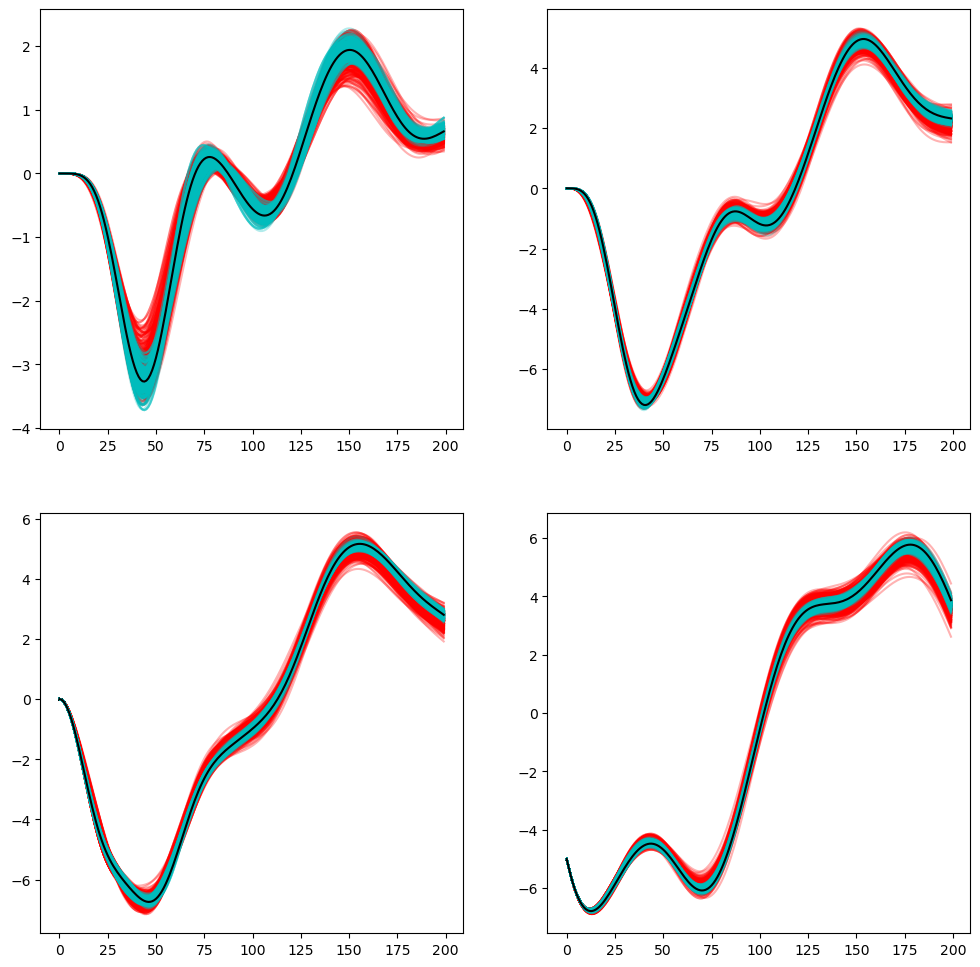

In [216]:
plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.plot(f_IND[:,0,:].T,color='r',alpha=0.3,label='IND')
plt.plot(f_MOP[:,0,:].T,color='c',alpha=0.3,label='MOP')
plt.plot(f_true[:,0],color='k')

plt.subplot(2,2,2)
plt.plot(f_IND[:,1,:].T,color='r',alpha=0.3,label='IND')
plt.plot(f_MOP[:,1,:].T,color='c',alpha=0.3,label='MOP')
plt.plot(f_true[:,1],color='k')

plt.subplot(2,2,3)
plt.plot(f_IND[:,2,:].T,color='r',alpha=0.3,label='IND')
plt.plot(f_MOP[:,2,:].T,color='c',alpha=0.3,label='MOP')
plt.plot(f_true[:,2],color='k')

plt.subplot(2,2,4)
plt.plot(f_IND[:,3,:].T,color='r',alpha=0.3,label='IND')
plt.plot(f_MOP[:,3,:].T,color='c',alpha=0.3,label='MOP')
plt.plot(f_true[:,3],color='k')
plt.show()

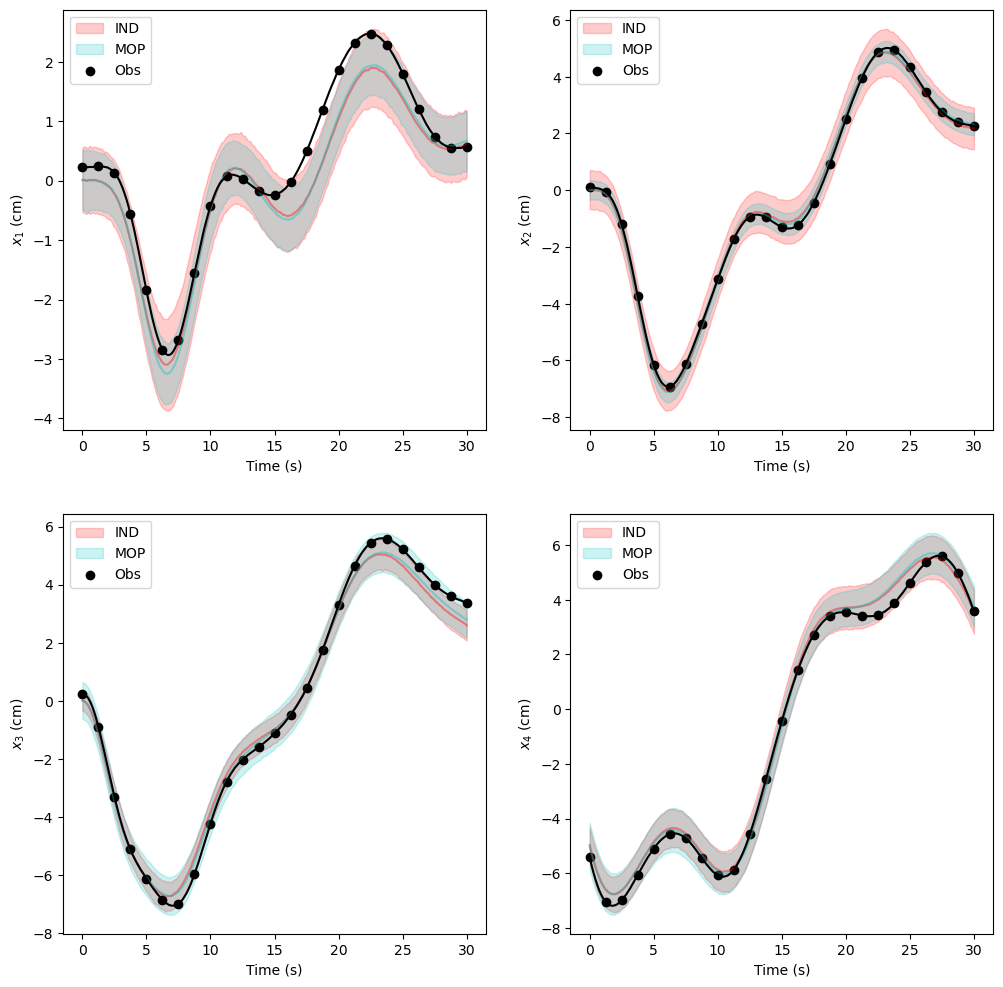

In [217]:
S_IND = f_IND[:,0,:].T+disc_IND[:,:,0].T+s2_samp_IND.detach().numpy().T*np.random.normal(0,1,(200,500))
I_IND = f_IND[:,1,:].T+disc_IND[:,:,1].T+s2_samp_IND.detach().numpy().T*np.random.normal(0,1,(200,500))
R_IND = f_IND[:,2,:].T+disc_IND[:,:,2].T+s2_samp_IND.detach().numpy().T*np.random.normal(0,1,(200,500))
V_IND = f_IND[:,3,:].T+disc_IND[:,:,3].T+s2_samp_IND.detach().numpy().T*np.random.normal(0,1,(200,500))

S_MOP = f_MOP[:,0,:].T+disc_MOP[:,:,0].T+s2_samp_MOP.detach().numpy().T*np.random.normal(0,1,(200,500))
I_MOP = f_MOP[:,1,:].T+disc_MOP[:,:,1].T+s2_samp_MOP.detach().numpy().T*np.random.normal(0,1,(200,500))
R_MOP = f_MOP[:,2,:].T+disc_MOP[:,:,2].T+s2_samp_MOP.detach().numpy().T*np.random.normal(0,1,(200,500))
V_MOP = f_MOP[:,3,:].T+disc_MOP[:,:,3].T+s2_samp_MOP.detach().numpy().T*np.random.normal(0,1,(200,500))


plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.fill_between(x,np.mean(S_IND,axis=1)+2*np.std(S_IND,axis=1),np.mean(S_IND,axis=1)-2*np.std(S_IND,axis=1),color='r',alpha=0.2,label='IND')
plt.plot(x,np.mean(S_IND,axis=1),color='r',alpha=0.4)
plt.fill_between(x,np.mean(S_MOP,axis=1)+2*np.std(S_MOP,axis=1),np.mean(S_MOP,axis=1)-2*np.std(S_MOP,axis=1),color='c',alpha=0.2,label='MOP')
plt.plot(x,np.mean(S_MOP,axis=1),color='c',alpha=0.4)
plt.plot(x,xi_true[:,0].detach().numpy(),color='k')
plt.scatter(x_obs,xi_obs[:,0],marker='o',color='k',label='Obs')
plt.ylabel(f'$x_1$ (cm)')
plt.xlabel('Time (s)')
plt.legend()


plt.subplot(2,2,2)
plt.fill_between(x,np.mean(I_IND,axis=1)+2*np.std(I_IND,axis=1),np.mean(I_IND,axis=1)-2*np.std(I_IND,axis=1),color='r',alpha=0.2,label='IND')
plt.plot(x,np.mean(I_IND,axis=1),color='r',alpha=0.4)
plt.fill_between(x,np.mean(I_MOP,axis=1)+2*np.std(I_MOP,axis=1),np.mean(I_MOP,axis=1)-2*np.std(I_MOP,axis=1),color='c',alpha=0.2,label='MOP')
plt.plot(x,np.mean(I_MOP,axis=1),color='c',alpha=0.4)
plt.plot(x,xi_true[:,1].detach().numpy(),color='k')
plt.scatter(x_obs,xi_obs[:,1],marker='o',color='k',label='Obs')
plt.ylabel(f'$x_2$ (cm)')
plt.xlabel('Time (s)')
plt.legend()

plt.subplot(2,2,3)
plt.fill_between(x,np.mean(R_IND,axis=1)+2*np.std(R_IND,axis=1),np.mean(R_IND,axis=1)-2*np.std(R_IND,axis=1),color='r',alpha=0.2,label='IND')
plt.plot(x,np.mean(R_IND,axis=1),color='r',alpha=0.4)
plt.fill_between(x,np.mean(R_MOP,axis=1)+2*np.std(R_MOP,axis=1),np.mean(R_MOP,axis=1)-2*np.std(R_MOP,axis=1),color='c',alpha=0.2,label='MOP')
plt.plot(x,np.mean(R_MOP,axis=1),color='c',alpha=0.4)
plt.plot(x,xi_true[:,2].detach().numpy(),color='k')
plt.scatter(x_obs,xi_obs[:,2],marker='o',color='k',label='Obs')
plt.ylabel(f'$x_3$ (cm)')
plt.xlabel('Time (s)')
plt.legend()


plt.subplot(2,2,4)
plt.fill_between(x,np.mean(V_IND,axis=1)+2*np.std(V_IND,axis=1),np.mean(V_IND,axis=1)-2*np.std(V_IND,axis=1),color='r',alpha=0.2,label='IND')
plt.plot(x,np.mean(V_IND,axis=1),color='r',alpha=0.4)
plt.fill_between(x,np.mean(V_MOP,axis=1)+2*np.std(V_MOP,axis=1),np.mean(V_MOP,axis=1)-2*np.std(V_MOP,axis=1),color='c',alpha=0.2,label='MOP')
plt.plot(x,np.mean(V_MOP,axis=1),color='c',alpha=0.4)
plt.plot(x,xi_true[:,3].detach().numpy(),color='k')
plt.scatter(x_obs,xi_obs[:,3],marker='o',color='k',label='Obs')
plt.ylabel(f'$x_4$ (cm)')
plt.xlabel('Time (s)')
plt.legend()

plt.show()

In [194]:
data_seed

92

In [195]:
import pickle

all_results = {
    'seed': data_seed,
    'obs': y_obs,
    'xi_true': xi_true,
    'UB': UB,
    'LB': LB,
    'theta_all_true': theta_all_true,
    'chain_IND': chain_IND,
    's2_IND': s2_IND,
    'chain_MOP': chain_MOP,
    's2_MOP': s2_MOP,
    'theta_samp_IND': theta_samp_IND,
    'theta_samp_MOP': theta_samp_MOP,
    's2_IND': s2_samp_IND,
    's2_MOP': s2_samp_MOP,
    'f_IND': f_IND,
    'f_MOP': f_MOP,
    'disc_IND': disc_IND,
    'disc_MOP': disc_MOP
}

In [196]:
with open('Spring_nolog_seed_92.pkl', 'wb') as f:
    pickle.dump(all_results, f)